In [6]:
import yfinance as yf

df = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
df.columns = df.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


EDA

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [39]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


In [40]:
df.shape

(1258, 5)

In [41]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [42]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1258 non-null   float64
 1   High    1258 non-null   float64
 2   Low     1258 non-null   float64
 3   Open    1258 non-null   float64
 4   Volume  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [43]:
df.describe()

Price,Close,High,Low,Open,Volume
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.377786,152.899566,149.680871,151.223470,9.057103e+07
std,41.851999,41.992363,41.629303,41.795805,5.324438e+07
min,54.163715,55.160713,51.324811,55.059324,2.323470e+07
25%,126.279102,127.397085,124.278511,125.724397,5.546825e+07
50%,149.968613,151.709750,148.037164,149.788897,7.628335e+07
75%,175.902031,177.452402,174.337260,175.708231,1.077425e+08
max,257.375580,258.448740,255.994420,256.550862,4.265100e+08


In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
print("Start Date:", df.index.min())
print("End Date:", df.index.max())

Start Date: 2020-01-02 00:00:00
End Date: 2024-12-31 00:00:00


In [46]:
df["Volume"].max()

np.int64(426510000)

Feature engineering

In [16]:
df["MA7"] = df["Close"].rolling(7).mean()

In [17]:
df["MA30"] = df["Close"].rolling(30).mean()

In [18]:
df["Daily Change"] = df["Close"] - df["Open"]

In [19]:
monthly_close = df["Close"].resample("ME").mean()

In [20]:
df["Daily Return"] = df["Close"].pct_change() * 100

In [ ]:
df.to_csv("Apple_Stock_Cleaned.csv")

In [22]:
df.to_csv("Apple_Stock_Cleaned.csv")

data visualisation

In [2]:
import matplotlib.pyplot as plt

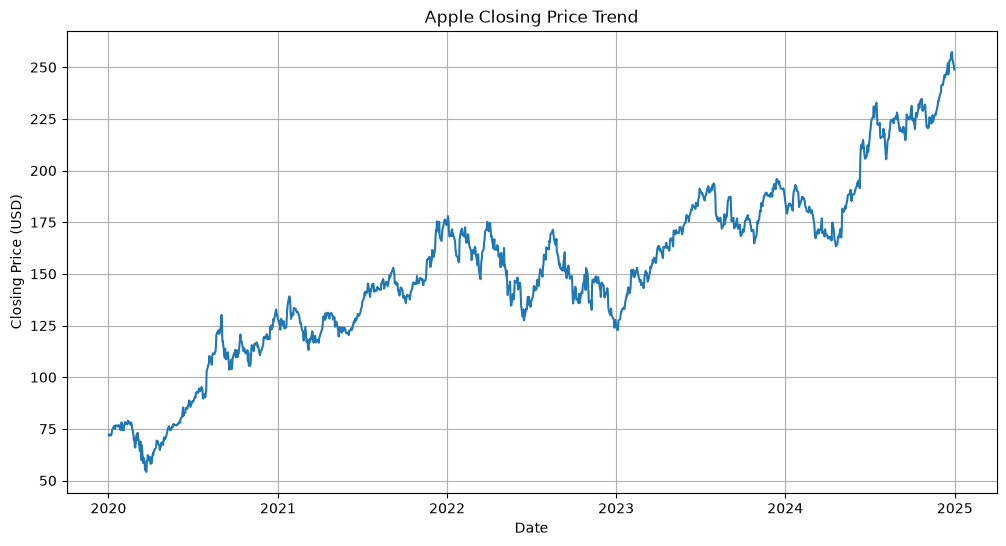

In [53]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"])
plt.title("Apple Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.grid(True)
plt.show()

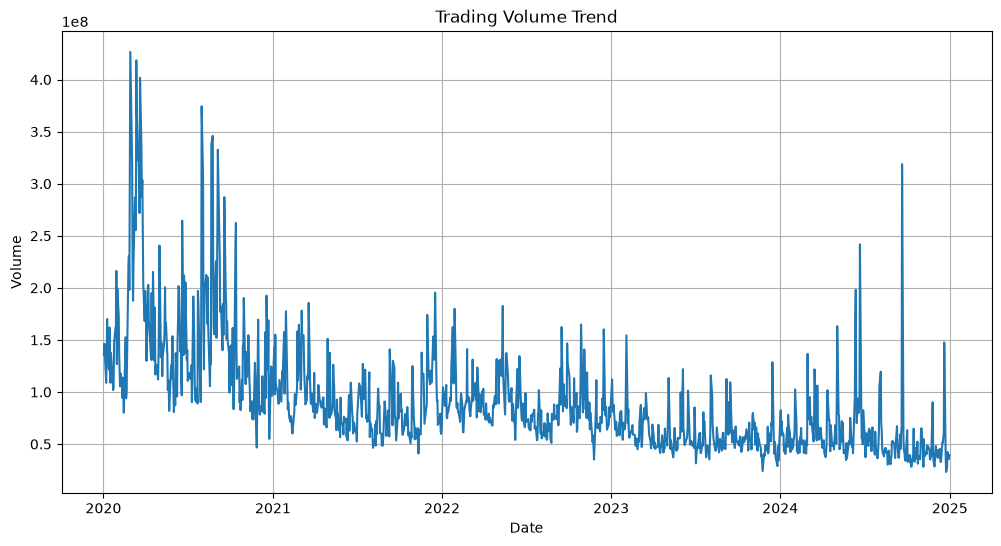

In [54]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Volume"])
plt.title("Trading Volume Trend")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

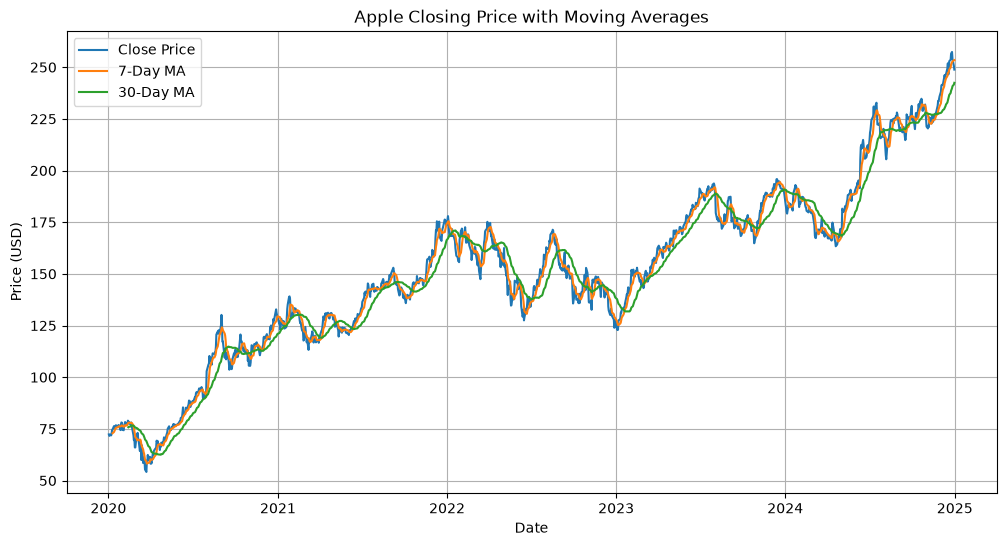

In [55]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Close"], label="Close Price")
plt.plot(df.index, df["MA7"], label="7-Day MA")
plt.plot(df.index, df["MA30"], label="30-Day MA")

plt.title("Apple Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

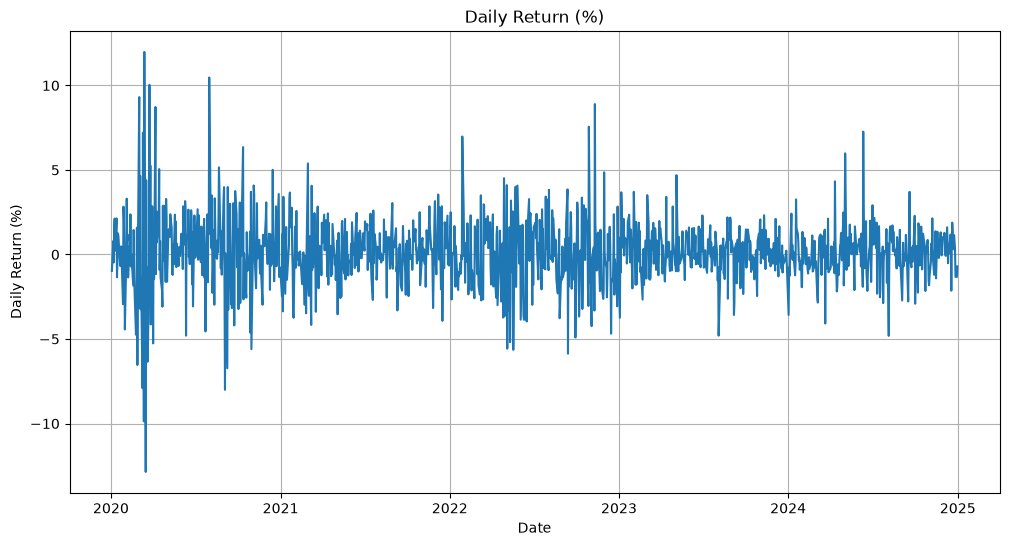

In [58]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Daily Return"])
plt.title("Daily Return (%)")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.grid(True)
plt.show()

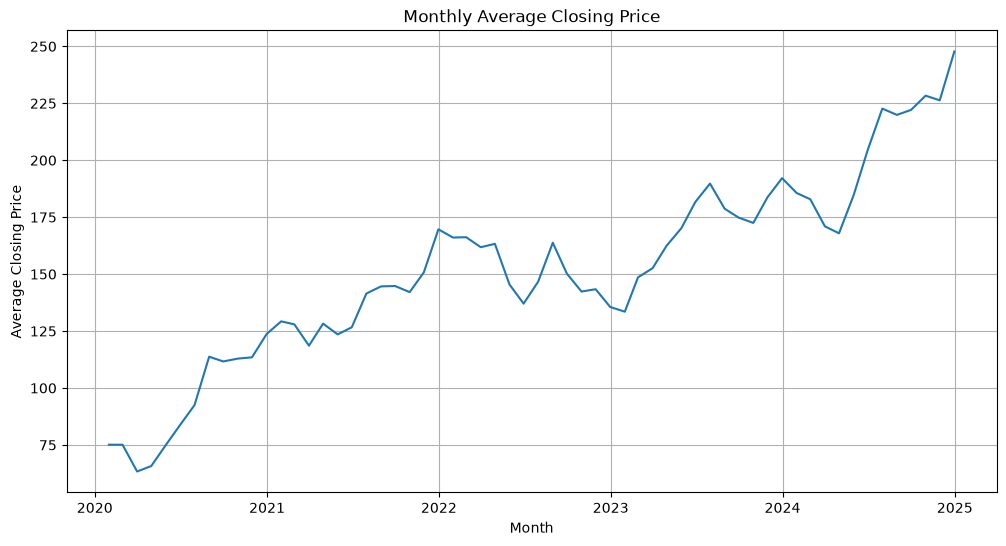

In [10]:
plt.figure(figsize=(12,6))
plt.plot(monthly_close.index, monthly_close)
plt.title("Monthly Average Closing Price")
plt.xlabel("Month")
plt.ylabel("Average Closing Price")
plt.grid(True)
plt.show()

In [ ]:

# Key Insights & Findings

1. Apple's closing stock price showed an overall upward trend from 2020 to 2024.

2. The 7-day Moving Average responded quickly to short-term price changes, while the 30-day Moving Average highlighted the long-term trend.

3. Trading volume fluctuated throughout the period, indicating changes in investor activity.

4. Daily returns showed both positive and negative movements, reflecting normal market fluctuations.

5. Monthly average closing prices generally increased over time, showing long-term growth.

Conclusion
Apple's stock demonstrated strong long-term growth despite short-term fluctuations. Moving averages helped identify market trends. Overall, the stock exhibited healthy long-term performance with temporary periods of higher risk.